# Stage 1: Isolating Analytic Approximations

The analytic intraband expression makes two approximations: (i) replacing $\rho(\mathcal{E})$ with $\rho(\mathcal{E}_F)$, and (ii) resolving $\int f(\mathcal{E}+\hbar\omega)[1-f(\mathcal{E})]\,d\mathcal{E}$ analytically. We compare against the numeric integral in two regimes: constant eDOS and varying eDOS. Relative errors are shown for $T=300, 500, 700\,\mathrm{K}$.


**Reference**

Numeric (Eq. 4):\n
$$ I^{T}(\hbar\omega) = \int_0^{\infty} f^{T}(\mathcal{E}+\hbar\omega)[1-f^{T}(\mathcal{E})]\,\rho(\mathcal{E}+\hbar\omega)\,\rho(\mathcal{E})\,d\mathcal{E} $$

Analytic approximation (Eq. 5):\n
$$ I^{T}_{\text{approx}}(\hbar\omega) = \rho^{2}(\mathcal{E}_{F})\,\frac{\hbar\omega}{\exp\left(\frac{\hbar\omega}{k_B T}\right)-1} $$

Relative error: $\delta_{\text{rel}} = (I_{\text{num}} - I_{\text{approx}})/I_{\text{approx}}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

plt.rcParams.update({"font.size": 12, "figure.dpi": 150})


In [2]:
# Constants (energy in eV)
k_B = 8.617333262145e-5
hbar = 6.582119569e-16
m_e = 5.485e-4
E_F = 3.0
T_list = [300.0, 500.0, 700.0]
T_F = E_F / k_B

# Energy integration grid for Eq. (4)
E_min = 0.0
E_max = 10.0
dE = 1e-3
E_grid = np.arange(E_min, E_max + dE, dE)

# Emission energy sweep (hbar*omega)
E_em_values = np.linspace(0.01, 8.0, 2000)
T_plot = T_list[0]  # temperature used for the top-row spectra


In [3]:
print('kbt =',k_B*300)
print('mu =',chemical_potential(300))

kbt = 0.025851999786435


NameError: name 'chemical_potential' is not defined

In [ ]:
1/(1-(np.pi**2/12))

5.632756660845568

In [ ]:
def density_of_states(E):
    return ((m_e ** 1.5) / (np.pi ** 2 * hbar ** 3)) * np.sqrt(2 * E)


g_F = density_of_states(E_F)


def chemical_potential(T):
    return E_F * (1 - (np.pi ** 2 / 12) * ((T / T_F) ** 2))


def fermi_dirac(E, T):
    mu = chemical_potential(T)
    return 1.0 / (np.exp((E - mu) / (k_B * T)) + 1)


def fermi_product_explicit(E, hw, T):
    # Explicitly compute f(E+hw)[1-f(E)] without subtracting from 1:
    #   f(E + hw)[1 - f(E)] = exp(beta*(E-mu)) / ((exp(beta*(E-mu)) + 1)(exp(beta*(E+hw-mu)) + 1))
    mu = chemical_potential(T)
    beta = 1.0 / (k_B * T)
    exp_E = np.exp(beta * (E - mu))
    exp_hw = np.exp(beta * hw)
    return exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))


def integrand_const(E, hw, T):
    fE = fermi_dirac(E, T)
    fEp = fermi_dirac(E + hw, T)
    return fEp * (1 - fE) * g_F * g_F


def integrand_const_explicit(E, hw, T):
    return fermi_product_explicit(E, hw, T) * g_F * g_F


def integrand_var(E, hw, T):
    fE = fermi_dirac(E, T)
    fEp = fermi_dirac(E + hw, T)
    return fEp * (1 - fE) * density_of_states(E + hw) * density_of_states(E)


def integrand_var_explicit(E, hw, T):
    return fermi_product_explicit(E, hw, T) * density_of_states(E + hw) * density_of_states(E)


def I_numeric_const(hw, T):
    return simpson(integrand_const(E_grid, hw, T), E_grid)


def I_numeric_const_explicit(hw, T):
    return simpson(integrand_const_explicit(E_grid, hw, T), E_grid)


def I_numeric_var(hw, T):
    return simpson(integrand_var(E_grid, hw, T), E_grid)


def I_numeric_var_explicit(hw, T):
    return simpson(integrand_var_explicit(E_grid, hw, T), E_grid)


def I_analytic(hw, T):
    return g_F**2 * hw / (np.exp(hw / (k_B * T)) - 1)


def I_analytic_explicit(hw, T):
    # Closed-form constant eDOS (no delta approximation)
    mu = chemical_potential(T)
    kBT = k_B * T
    beta = 1.0 / kBT
    hw = np.asarray(hw, dtype=float)
    bracket = beta * hw + np.log1p(np.exp(-beta * mu)) - np.log1p(np.exp(beta * (hw - mu)))
    return g_F**2 * (kBT / np.expm1(beta * hw)) * bracket


In [ ]:
I_num_const = {}
I_num_const_explicit = {}
I_num_var = {}
I_ana = {}
I_ana_explicit = {}
abs_delta_const = {}
abs_delta_const_explicit = {}
abs_delta_var = {}
abs_diff_const_num = {}
abs_delta_ana_vs_exact = {}
abs_delta_num_vs_exact = {}

for T in T_list:
    I_num_const[T] = np.array([I_numeric_const(hw, T) for hw in E_em_values])
    I_num_const_explicit[T] = np.array([I_numeric_const_explicit(hw, T) for hw in E_em_values])
    I_num_var[T] = np.array([I_numeric_var(hw, T) for hw in E_em_values])
    I_ana[T] = I_analytic(E_em_values, T)
    I_ana_explicit[T] = I_analytic_explicit(E_em_values, T)

    abs_delta_const[T] = np.abs((I_num_const[T] - I_ana[T]) / I_ana[T])
    abs_delta_const_explicit[T] = np.abs((I_num_const_explicit[T] - I_ana[T]) / I_ana[T])
    abs_delta_var[T] = np.abs((I_num_var[T] - I_ana[T]) / I_ana[T])

    abs_diff_const_num[T] = np.abs(I_num_const_explicit[T] - I_num_const[T]) / np.maximum(
        np.abs(I_num_const_explicit[T]), 1e-300
    )
    abs_delta_num_vs_exact[T] = np.abs((I_num_const[T] - I_ana_explicit[T]) / I_ana_explicit[T])
    abs_delta_ana_vs_exact[T] = np.abs((I_ana[T] - I_ana_explicit[T]) / I_ana_explicit[T])

    print(
        f"T={T:4.0f} K | const eDOS (f*(1-f)) max/median |delta_rel| = {abs_delta_const[T].max():.3e}/{np.median(abs_delta_const[T]):.3e}"
    )
    print(
        f"T={T:4.0f} K | const eDOS (explicit) max/median |delta_rel| = {abs_delta_const_explicit[T].max():.3e}/{np.median(abs_delta_const_explicit[T]):.3e}"
    )
    print(f"T={T:4.0f} K | const eDOS max rel |numeric diff| = {abs_diff_const_num[T].max():.3e}")
    print(
        f"T={T:4.0f} K | const eDOS numeric vs analytic-explicit max/median |delta_rel| = {abs_delta_num_vs_exact[T].max():.3e}/{np.median(abs_delta_num_vs_exact[T]):.3e}"
    )
    print(
        f"T={T:4.0f} K | analytic approx vs analytic explicit max/median |delta_rel| = {abs_delta_ana_vs_exact[T].max():.3e}/{np.median(abs_delta_ana_vs_exact[T]):.3e}"
    )
    print(
        f"T={T:4.0f} K | vary  eDOS max/median |delta_rel| = {abs_delta_var[T].max():.3e}/{np.median(abs_delta_var[T]):.3e}"
    )


/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_60783/3859285266.py:24: RuntimeWarning: overflow encountered in multiply
  return exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))


T= 300 K | const eDOS (f*(1-f)) max/median |delta_rel| = 8.805e-01/7.612e-01
T= 300 K | const eDOS (explicit) max/median |delta_rel| = 6.250e-01/2.510e-01
T= 300 K | const eDOS max rel |numeric diff| = 6.812e-01
T= 300 K | const eDOS numeric vs analytic-explicit max/median |delta_rel| = 6.812e-01/6.812e-01
T= 300 K | analytic approx vs analytic explicit max/median |delta_rel| = 1.667e+00/3.351e-01
T= 300 K | vary  eDOS max/median |delta_rel| = 7.949e-01/6.772e-01
T= 500 K | const eDOS (f*(1-f)) max/median |delta_rel| = 8.006e-01/6.017e-01
T= 500 K | const eDOS (explicit) max/median |delta_rel| = 6.251e-01/2.511e-01
T= 500 K | const eDOS max rel |numeric diff| = 4.681e-01
T= 500 K | const eDOS numeric vs analytic-explicit max/median |delta_rel| = 4.681e-01/4.681e-01
T= 500 K | analytic approx vs analytic explicit max/median |delta_rel| = 1.667e+00/3.352e-01
T= 500 K | vary  eDOS max/median |delta_rel| = 6.859e-01/5.100e-01
T= 700 K | const eDOS (f*(1-f)) max/median |delta_rel| = 7.208e-

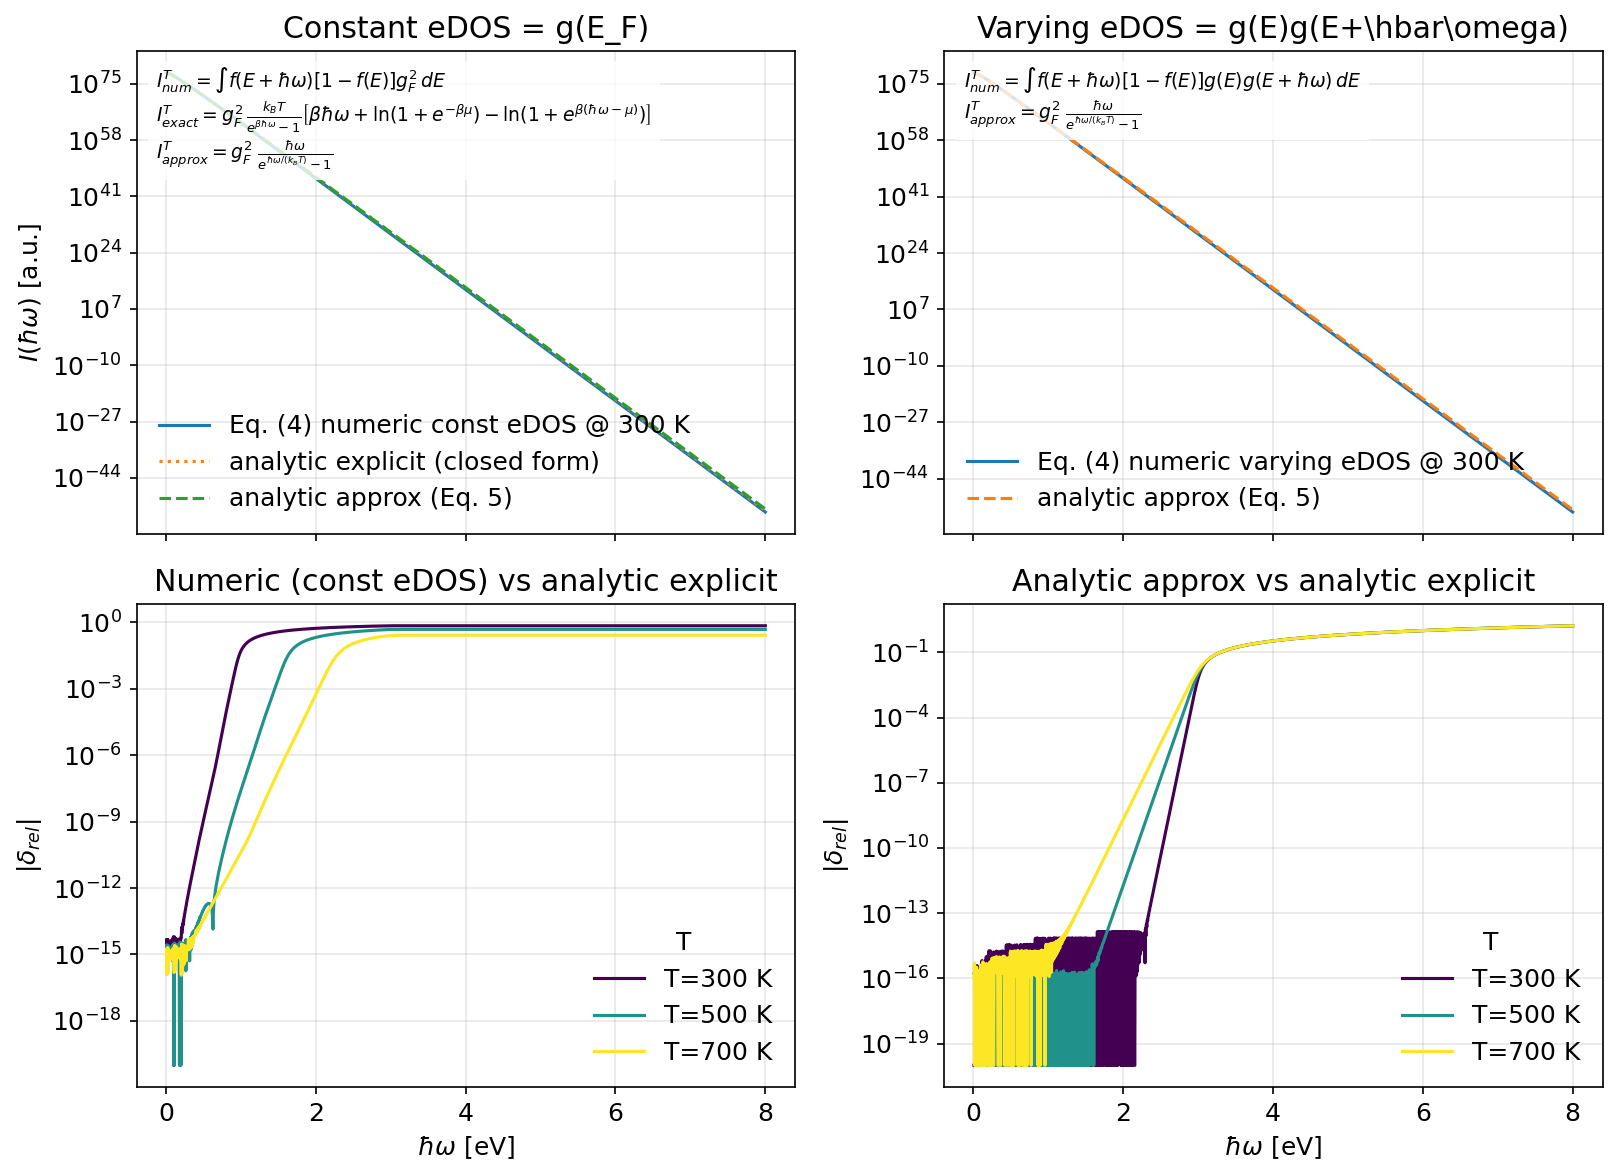

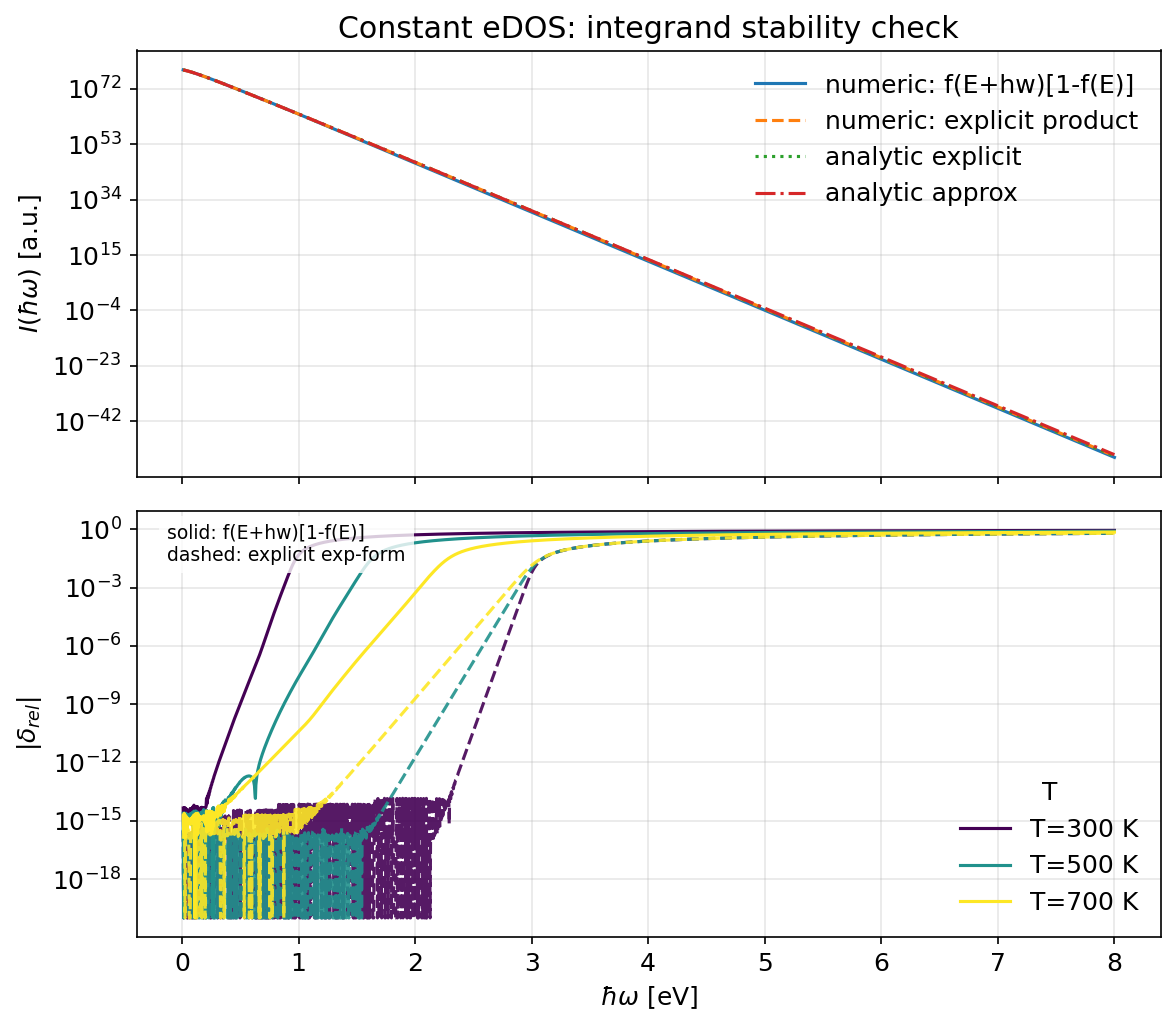

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex="col")

# --- Spectra at T_plot ---
axes[0, 0].plot(E_em_values, I_num_const[T_plot], label=f"Eq. (4) numeric const eDOS @ {T_plot:.0f} K")
axes[0, 0].plot(E_em_values, I_ana_explicit[T_plot], linestyle=":", label="analytic explicit (closed form)")
axes[0, 0].plot(E_em_values, I_ana[T_plot], linestyle="--", label="analytic approx (Eq. 5)")
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel(r"$I(\hbar\omega)$ [a.u.]")
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_title("Constant eDOS = g(E_F)")
axes[0, 0].text(
    0.03,
    0.97,
    (
        r"$I^{T}_{num}=\int f(E+\hbar\omega)[1-f(E)] g_F^2\,dE$"
        "\n"
        r"$I^{T}_{exact}=g_F^2\,\frac{k_B T}{e^{\beta\hbar\omega}-1}\left[\beta\hbar\omega+\ln(1+e^{-\beta\mu})-\ln(1+e^{\beta(\hbar\omega-\mu)})\right]$"
        "\n"
        r"$I^{T}_{approx}= g_F^2 \; \frac{\hbar\omega}{e^{\hbar\omega/(k_B T)}-1}$"
    ),
    transform=axes[0, 0].transAxes,
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

axes[0, 1].plot(E_em_values, I_num_var[T_plot], label=f"Eq. (4) numeric varying eDOS @ {T_plot:.0f} K")
axes[0, 1].plot(E_em_values, I_ana[T_plot], linestyle="--", label="analytic approx (Eq. 5)")
axes[0, 1].set_yscale("log")
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_title(r"Varying eDOS = g(E)g(E+\hbar\omega)")
axes[0, 1].text(
    0.03,
    0.97,
    (
        r"$I^{T}_{num}=\int f(E+\hbar\omega)[1-f(E)] g(E)g(E+\hbar\omega)\,dE$"
        "\n"
        r"$I^{T}_{approx}= g_F^2 \; \frac{\hbar\omega}{e^{\hbar\omega/(k_B T)}-1}$"
    ),
    transform=axes[0, 1].transAxes,
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

# --- Relative errors (constant eDOS) ---
colors = plt.cm.viridis(np.linspace(0, 1, len(T_list)))
for color, T in zip(colors, T_list):
    axes[1, 0].plot(
        E_em_values,
        np.clip(abs_delta_num_vs_exact[T], 1e-20, None),
        label=f"T={T:.0f} K",
        color=color,
    )
    axes[1, 1].plot(
        E_em_values,
        np.clip(abs_delta_ana_vs_exact[T], 1e-20, None),
        label=f"T={T:.0f} K",
        color=color,
    )

axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel(r"$\hbar\omega$ [eV]")
axes[1, 0].set_ylabel(r"$|\delta_{rel}|$")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(frameon=False, title="T")
axes[1, 0].set_title("Numeric (const eDOS) vs analytic explicit")

axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel(r"$\hbar\omega$ [eV]")
axes[1, 1].set_ylabel(r"$|\delta_{rel}|$")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(frameon=False, title="T")
axes[1, 1].set_title("Analytic approx vs analytic explicit")

plt.tight_layout()
plt.show()

# --- Stability check: explicit product form (constant eDOS) ---
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(E_em_values, I_num_const[T_plot], label="numeric: f(E+hw)[1-f(E)]")
axes[0].plot(
    E_em_values,
    I_num_const_explicit[T_plot],
    linestyle="--",
    label="numeric: explicit product",
)
axes[0].plot(E_em_values, I_ana_explicit[T_plot], linestyle=":", label="analytic explicit")
axes[0].plot(E_em_values, I_ana[T_plot], linestyle="-.", label="analytic approx")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$I(\hbar\omega)$ [a.u.]")
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=False)
axes[0].set_title("Constant eDOS: integrand stability check")

for color, T in zip(colors, T_list):
    axes[1].plot(
        E_em_values,
        np.clip(abs_delta_const[T], 1e-20, None),
        color=color,
        label=f"T={T:.0f} K",
    )
    axes[1].plot(
        E_em_values,
        np.clip(abs_delta_const_explicit[T], 1e-20, None),
        color=color,
        linestyle="--",
        alpha=0.9,
    )

axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\hbar\omega$ [eV]")
axes[1].set_ylabel(r"$|\delta_{rel}|$")
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=False, title="T")
axes[1].text(
    0.03,
    0.97,
    "solid: f(E+hw)[1-f(E)]\n" "dashed: explicit exp-form",
    transform=axes[1].transAxes,
    va="top",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
)

plt.tight_layout()
plt.show()


- results are, unsurprisingly, better for the left side in which both expressions assume a constant eDOS, and worse for the 

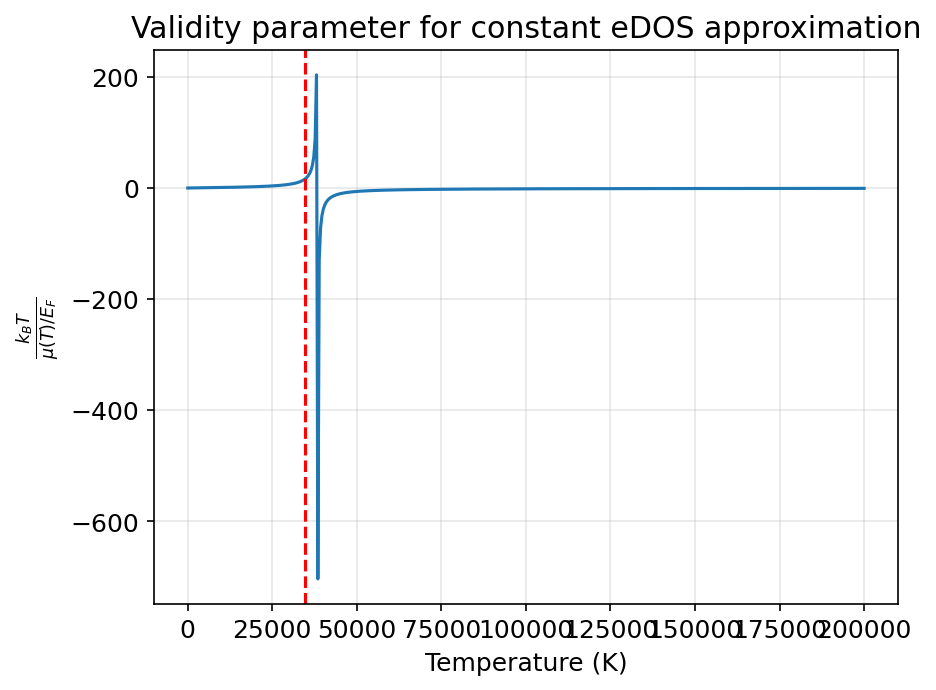

In [ ]:
def f(T):
    return (k_B*T) / (chemical_potential(T)/E_F)

T = np.linspace(1, 200000, 500)
f_T = f(T)
plt.plot(T, f_T)
plt.xlabel("Temperature (K)")
plt.ylabel(r"$\frac{k_B T}{\mu(T)/E_F}$")
plt.title("Validity parameter for constant eDOS approximation")
plt.axvline(x=T_F, color='red', linestyle='--', label=r'$T_F$')
plt.grid(alpha=0.3)

In [ ]:
def I_numeric_const_eDOS(hw, T):
    """Numeric Eq. (4) with constant eDOS = g(E_F)^2, using an explicit stable form."""
    mu = chemical_potential(T)
    beta = 1.0 / (k_B * T)

    exp_E = np.exp(beta * (E_grid - mu))
    exp_hw = np.exp(beta * hw)

    # f(E+hw)[1-f(E)] = exp(beta*(E-mu)) / ((exp(beta*(E-mu))+1)(exp(beta*(E+hw-mu))+1))
    integrand = exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))
    return g_F**2 * simpson(integrand, x=E_grid)


def I_numeric_const_eDOS_sweep(hw_values, T):
    hw_values = np.asarray(hw_values, dtype=float)
    return np.array([I_numeric_const_eDOS(hw, T) for hw in hw_values])


def I_analytic_const_eDOS_exact(hw, T):
    """Analytic constant-eDOS result (no μ ≫ k_B T approximation)."""
    hw = np.asarray(hw, dtype=float)
    mu = chemical_potential(T)
    beta = 1.0 / (k_B * T)

    x = beta * hw
    bracket = x + np.logaddexp(0.0, -beta * mu) - np.logaddexp(0.0, beta * (hw - mu))
    denom = np.expm1(x)

    ratio = np.where(x == 0.0, 1.0, bracket / denom)
    return g_F**2 * k_B * T * ratio


def I_analytic_const_eDOS_exact_sweep(hw_values, T):
    hw_values = np.asarray(hw_values, dtype=float)
    return I_analytic_const_eDOS_exact(hw_values, T)


/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_60783/1233803867.py:10: RuntimeWarning: overflow encountered in multiply
  integrand = exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))


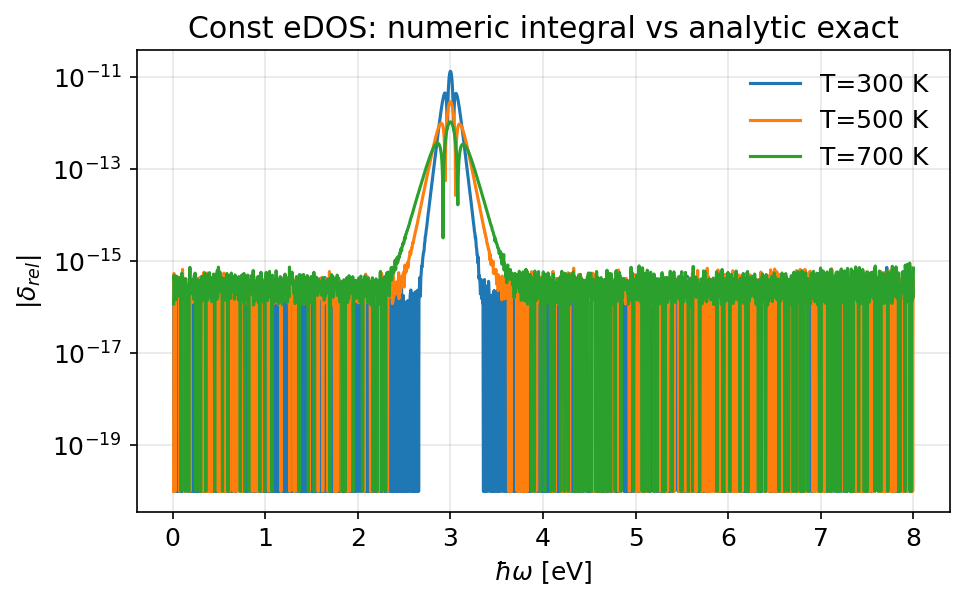

In [ ]:
# Relative error: numeric const-eDOS integral vs analytic exact (closed form)
rel_err_num_vs_exact = {}
for T in T_list:
    I_num = I_numeric_const_eDOS_sweep(E_em_values, T)
    I_exact = I_analytic_const_eDOS_exact_sweep(E_em_values, T)
    rel_err_num_vs_exact[T] = np.abs((I_num - I_exact) / I_exact)

plt.figure(figsize=(7, 4))
for T in T_list:
    plt.semilogy(E_em_values, np.clip(rel_err_num_vs_exact[T], 1e-20, None), label=f"T={T:.0f} K")
plt.xlabel(r"$\hbar\omega$ [eV]")
plt.ylabel(r"$|\delta_{rel}|$")
plt.title("Const eDOS: numeric integral vs analytic exact")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.show()


/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_60783/2103518798.py:17: RuntimeWarning: overflow encountered in multiply
  integrand = exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))


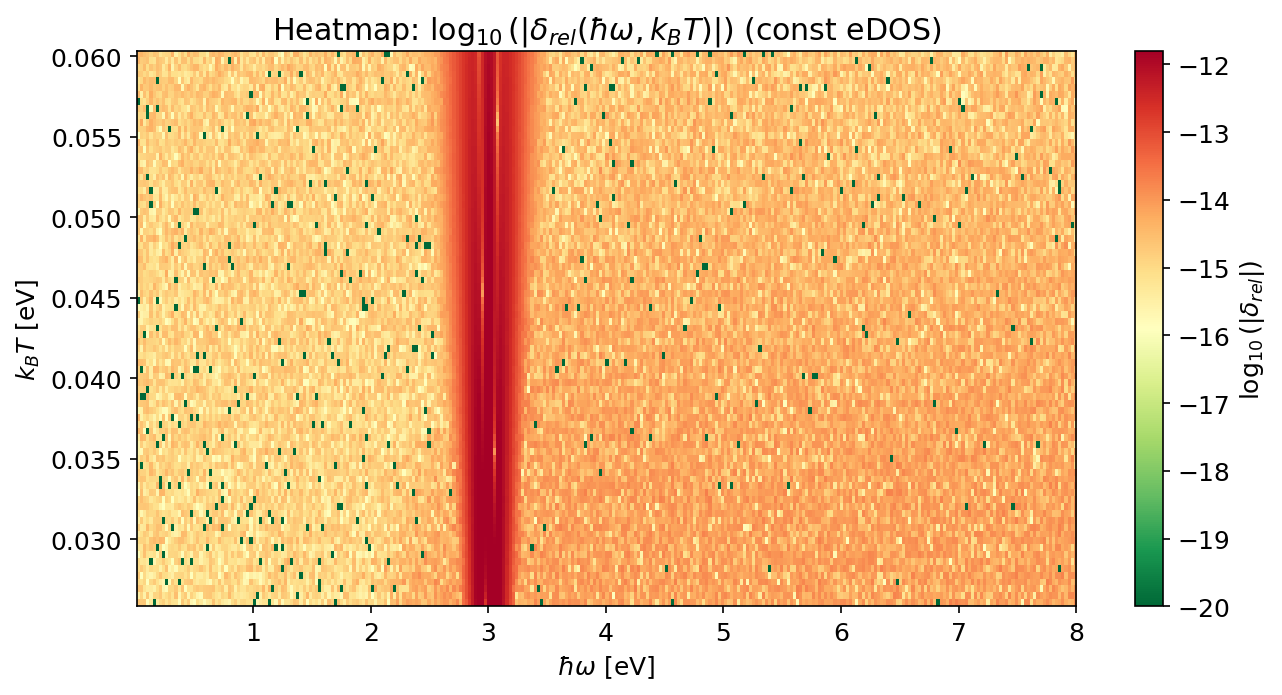

In [ ]:
# Heatmap: log10(|delta_rel(hbar*omega, k_B*T)|) for const-eDOS numeric vs analytic exact
# (This visualizes quadrature error as a function of emission energy and temperature.)

hw_heat = np.linspace(E_em_values.min(), E_em_values.max(), 301)
T_heat = np.linspace(min(T_list), max(T_list), 81)
kBT_heat = k_B * T_heat

log10_err = np.empty((len(T_heat), len(hw_heat)))

for i, T in enumerate(T_heat):
    mu = chemical_potential(T)
    beta = 1.0 / (k_B * T)

    exp_E = np.exp(beta * (E_grid - mu))[:, None]
    exp_hw = np.exp(beta * hw_heat)[None, :]

    integrand = exp_E / ((exp_E + 1) * (exp_E * exp_hw + 1))
    I_num = g_F**2 * simpson(integrand, x=E_grid, axis=0)
    I_exact = I_analytic_const_eDOS_exact(hw_heat, T)

    rel_err = np.abs((I_num - I_exact) / I_exact)
    log10_err[i, :] = np.log10(np.clip(rel_err, 1e-20, None))

vmin = -20
vmax = float(np.nanpercentile(log10_err, 99))
if not np.isfinite(vmax) or vmax <= vmin:
    vmax = vmin + 1

plt.figure(figsize=(9, 4.8))
im = plt.imshow(
    log10_err,
    origin="lower",
    aspect="auto",
    extent=[hw_heat.min(), hw_heat.max(), kBT_heat.min(), kBT_heat.max()],
    cmap="RdYlGn_r",
    vmin=vmin,
    vmax=vmax,
)
plt.colorbar(im, label=r"$\log_{10}(|\delta_{rel}|)$")
plt.xlabel(r"$\hbar\omega$ [eV]")
plt.ylabel(r"$k_B T$ [eV]")
plt.title(r"Heatmap: $\log_{10}(|\delta_{rel}(\hbar\omega, k_B T)|)$ (const eDOS)")
plt.tight_layout()
plt.show()
